# Chapter 12: Quantum Encoding


---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from Chapter04_EngineeringProblems_functions import (truss2x2,truss3x2,truss2x3,truss3x3,truss_10bar,
                                                         PlaneStressCantilever)
from Chapter08_QuantumGates_functions import  (simulate_statevector,  simulate_measurements, 
                                              estimateCircuitGates, findActualHardwareRequirements)


from qiskit_aer.noise import NoiseModel, depolarizing_error
BASIS = ['cx', 'u', 'x', 'h', 'ry', 'rz', 'rx', 'p']   # transpilation basis

## Hand-crafted encoding 

<IPython.core.display.Latex object>

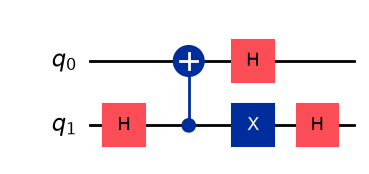

--- Circuit Analysis ---
Qubits: 2
Single-qubit gates: 3
CX/ECR gates: 1
Total gates: 4
Depth: 3
{'num_qubits': 2, 'single_gate_count': 3, 'cx_gates': 1, 'total_gates': 4, 'depth': 3, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000023E4596F150>}


In [2]:
m = 2
N = 2**m

example = 9
qc = QuantumCircuit(m)
if (example == 1):
    pass # nothing to do
elif (example == 2):
    qc.x(0)
elif (example == 3):
    qc.h(range(m))
elif (example == 4):
    qc.x(0)
    qc.h(range(m))
elif (example == 5):
    qc.x(m-1)
    qc.h(range(m))
elif (example == 6):
    qc.ry(np.pi/3,0)
elif (example == 7):
    b = np.array([1/2, np.sqrt(3)/2])
    theta = 2*np.arctan(b[1]/b[0])
    qc.ry(theta,0)
elif (example == 8):
    theta = 2*np.arctan2(1/2, np.sqrt(3)/2) 
    qc.ry(theta, 0)
    qc.s(0)
elif (example == 9):
    qc.h(1)
    qc.cx(1, 0)
    qc.x(1)
    qc.h(range(2))


state = Statevector.from_instruction(qc)
display(state.draw("latex"))

qc.draw("mpl")
display(qc.draw("mpl"))

circuitData = estimateCircuitGates(qc)
print(circuitData)


## Structured encoding via PyEncode

### Walsh function

# PyEncode — emitted circuit: WALSH k=0, c0=1.0, c1=-1.0 — period P=2^(k+1)=2
# m = 3 qubits,  N = 8 nodes
# Edit freely; run as standalone Qiskit code.

from qiskit import QuantumCircuit


m = 3
qc = QuantumCircuit(m, name='walsh')
qc.x(0)          # standard Walsh: X = R_y(pi)
for q in range(m):
    qc.h(q)


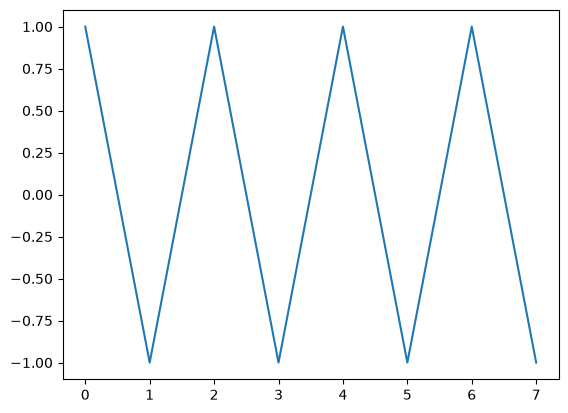

In [3]:
from pyencode import (encode, WALSH)
m = 3
N = 2**m
circuit, info = encode(WALSH(k=0, c0=1, c1=-1), N=N,validate=True)

print(info.circuit_code)
circuit.draw("mpl")
plt.plot(info.vector)

### Geometric

In [4]:
from pyencode import (encode, GEOMETRIC)
m = 3
N = 2**m
circuit, info = encode(GEOMETRIC(0.5), N=N,validate=True)

print(info.circuit_code)
print(info.vector)


# PyEncode — emitted circuit: GEOMETRIC  r=0.5, c=1.0
# m = 3 qubits,  N = 8 nodes
# Edit freely; run as standalone Qiskit code.

from qiskit import QuantumCircuit

import math

m = 3
r = 0.5
qc = QuantumCircuit(m, name='geometric')

# Product state: each qubit j gets R_y(2*arctan(r^(2^j)))
for j in range(m):
    theta_j = 2.0 * math.atan(r ** (2 ** j))
    qc.ry(theta_j, j)
[1.        0.5       0.25      0.125     0.0625    0.03125   0.015625
 0.0078125]


## Qiskit's initialize

<IPython.core.display.Latex object>

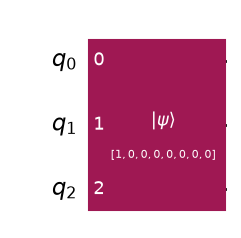

--- Circuit Analysis ---
Qubits: 3
Single-qubit gates: 3
CX/ECR gates: 0
Total gates: 3
Depth: 1
{'num_qubits': 3, 'single_gate_count': 3, 'cx_gates': 0, 'total_gates': 3, 'depth': 1, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000023E45B82C10>}


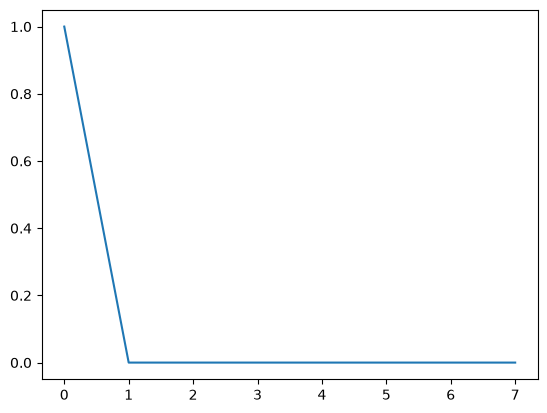

In [5]:
example = 1
if (example == 1):
    b = np.zeros(N)
    b[0] = 1
elif (example == 2):
    b = np.zeros(N)
    b[1] = 1
elif (example == 3):
    b = np.ones((N))
elif (example == 4):
    b = np.ones((N))
    b[1::2] = -1 # 1, 3 ... entries are negative
elif (example == 5):
    b = np.ones((N))
    b[N//2:] = -1 # second half of the entries are negative
elif (example == 6):
    b = np.zeros((N))
    b[0] = np.sqrt(3)/2 
    b[1] = 1/2
elif (example == 7):
    b = np.zeros((N))
    b[0] = np.sqrt(10)/5 
    b[1] = np.sqrt(15)/5 
elif (example == 8):
    b = np.zeros((N),dtype=complex)
    b[0] = np.sqrt(3)/2 
    b[1] = 1j/2
b = b/np.linalg.norm(b)

qc = QuantumCircuit(m)
qc.initialize(b, range(m))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))

plt.plot(b.real, label="Real Part")
qc.draw("mpl")
display(qc.draw("mpl"))

circuitData = estimateCircuitGates(qc)
print(circuitData)  


## Transpiled circuit

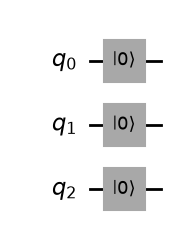

--- Circuit Analysis ---
Qubits: 3
Single-qubit gates: 3
CX/ECR gates: 0
Total gates: 3
Depth: 1
{'num_qubits': 3, 'single_gate_count': 3, 'cx_gates': 0, 'total_gates': 3, 'depth': 1, 'transpiled_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000023E45B7C250>}


In [6]:
transpiled_circuit = transpile(qc, basis_gates=BASIS)
display(transpiled_circuit.draw("mpl"))
circuitData = estimateCircuitGates(transpiled_circuit)
print(circuitData)  

## Structured Encoding

## Mottonen decomposition
### $\ket{\psi} = \sqrt{0.3}\ket{00} + \sqrt{0.1}\ket{01} + \sqrt{0.2}\ket{10} + \sqrt{0.4}\ket{11}$

<IPython.core.display.Latex object>

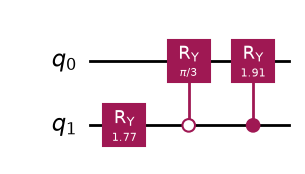

In [7]:
# psi = [np.sqrt(0.3), np.sqrt(0.1), np.sqrt(0.2), np.sqrt(0.4)]

# Total prob for q1=0 is 0.4, for q1=1 is 0.6
theta_1 = 2 * np.arctan2(np.sqrt(0.6), np.sqrt(0.4))

# If q1=0, split 0.4 into 0.3 and 0.1
theta_00 = 2 * np.arctan2(np.sqrt(0.1), np.sqrt(0.3))

# If q1=1, split 0.6 into 0.2 and 0.4
theta_10 = 2 * np.arctan2(np.sqrt(0.4), np.sqrt(0.2))

qc = QuantumCircuit(2)
qc.ry(theta_1, 1)
qc.cry(theta_00, 1, 0, ctrl_state='0')
qc.cry(theta_10, 1, 0, ctrl_state='1') 

state = Statevector.from_instruction(qc)
display(state.draw('latex'))
display(qc.draw('mpl'))

## Mottonen decomposition 
### $\ket{\psi} = \sqrt{0.3}\ket{00} + i\sqrt{0.2}\ket{01} + \sqrt{0.1}\ket{10} - i\sqrt{0.4}\ket{11}$

<IPython.core.display.Latex object>

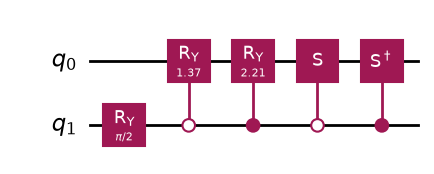

In [8]:
# Level 1 & 2: magnitude tree (identical to real-amplitude example)
theta_1  = np.pi/2
theta_00 = 2*np.arctan2(np.sqrt(0.2), np.sqrt(0.3))   # ~1.352 rad
theta_10 = 2*np.arctan2(np.sqrt(0.4), np.sqrt(0.1))   # ~2.214 rad

qc = QuantumCircuit(2)
qc.ry(theta_1,  1)
qc.cry(theta_00, 1, 0, ctrl_state='0')   # left branch
qc.cry(theta_10, 1, 0, ctrl_state='1')   # right branch

# Level 3: phase layer using S and Sdg (no global phase ambiguity)
# |01>: phase +i -> controlled-S on q0, active when q1=0 and q0=1
qc.cs(1, 0, ctrl_state='0')              # S on q0 controlled on q1=0

# |11>: phase -i -> controlled-Sdg on q0, active when q1=1 and q0=1
qc.csdg(1, 0, ctrl_state='1')           # Sdg on q0 controlled on q1=1
state = Statevector.from_instruction(qc)
display(state.draw('latex'))
display(qc.draw('mpl'))

## Mottonen, 3 qubit

<IPython.core.display.Latex object>

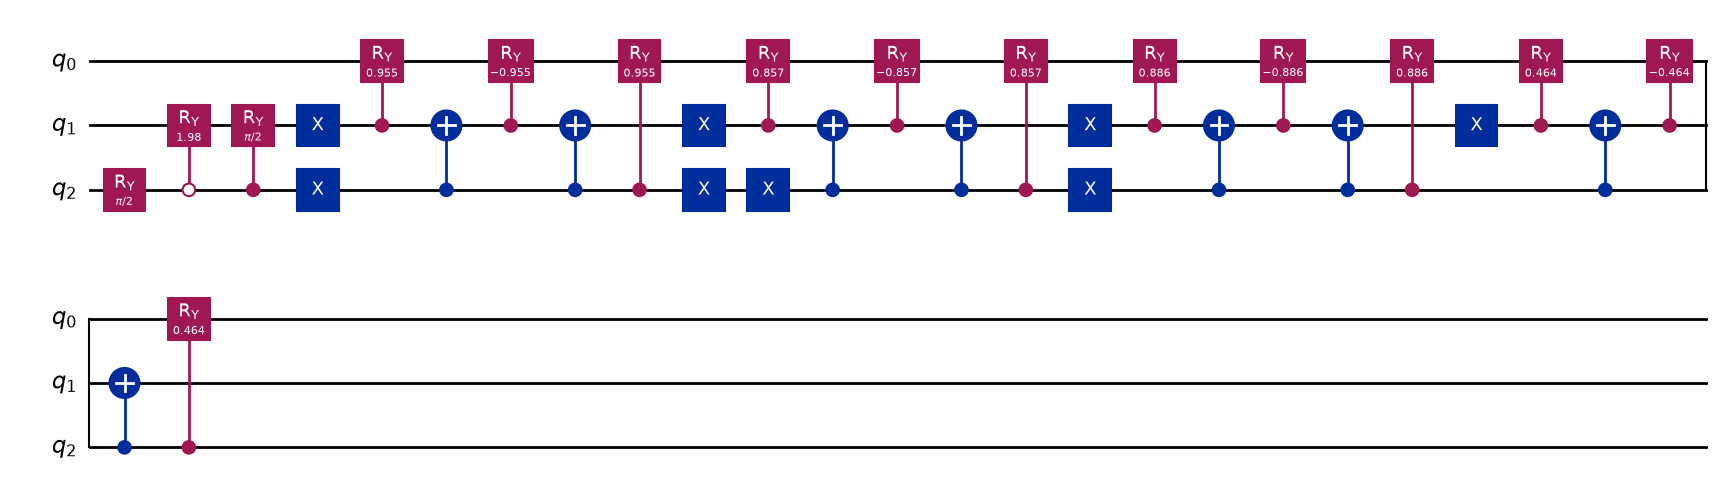

In [9]:
p = [0.05, 0.10, 0.15, 0.20, 0.10, 0.15, 0.20, 0.05]

# Level 1: q2
theta_2   = 2*np.arctan2(np.sqrt(0.50), np.sqrt(0.50))   # ~1.571

# Level 2: q1 | q2
theta_02  = 2*np.arctan2(np.sqrt(p[2]+p[3]), np.sqrt(p[0]+p[1]))  # q2=0
theta_12  = 2*np.arctan2(np.sqrt(p[6]+p[7]), np.sqrt(p[4]+p[5]))  # q2=1

# Level 3: q0 | q2,q1
theta_002 = 2*np.arctan2(np.sqrt(p[1]), np.sqrt(p[0]))   # q2=0, q1=0
theta_012 = 2*np.arctan2(np.sqrt(p[3]), np.sqrt(p[2]))   # q2=0, q1=1
theta_102 = 2*np.arctan2(np.sqrt(p[5]), np.sqrt(p[4]))   # q2=1, q1=0
theta_112 = 2*np.arctan2(np.sqrt(p[7]), np.sqrt(p[6]))   # q2=1, q1=1

qc = QuantumCircuit(3)
qc.ry(theta_2,  2)                              # level 1
qc.cry(theta_02, 2, 1, ctrl_state='0')          # level 2: q2=0
qc.cry(theta_12, 2, 1, ctrl_state='1')          # level 2: q2=1

# level 3: doubly-controlled Ry via standard decomposition
# ccry(theta, ctrl1, ctrl2, tgt) uses X gates to handle ctrl_state
def ccry(qc, theta, ctrl1, ctrl2, tgt, c1_state='1', c2_state='1'):
    """
    Apply a doubly-controlled R_y(theta) using the standard 2-CX decomposition.

    Realizes a Toffoli-style controlled rotation without an ancilla by splitting
    R_y(theta) into three controlled R_y(±theta/2) rotations interleaved with two
    CX gates. Requested control states are handled by conjugating the relevant
    control qubit with X gates, so any combination of 0/1 control values is
    supported. This builds the third level of the amplitude-encoding tree.

    Parameters
    ----------
    qc : qiskit.QuantumCircuit
        Circuit the gates are appended to, in place.
    theta : float
        Rotation angle applied to the target when both controls are active.
    ctrl1, ctrl2 : int
        Indices of the two control qubits.
    tgt : int
        Index of the target qubit receiving the R_y rotation.
    c1_state, c2_state : str, optional
        Desired activation state ('0' or '1') of ctrl1 and ctrl2 respectively.
        A '0' wraps that control in X gates. Both default to '1'.

    Returns
    -------
    None
        The gates are added to ``qc`` as a side effect.
    """
    if c1_state == '0': qc.x(ctrl1)
    if c2_state == '0': qc.x(ctrl2)
    qc.cry(theta/2,  ctrl2, tgt)
    qc.cx(ctrl1, ctrl2)
    qc.cry(-theta/2, ctrl2, tgt)
    qc.cx(ctrl1, ctrl2)
    qc.cry(theta/2,  ctrl1, tgt)
    if c1_state == '0': qc.x(ctrl1)
    if c2_state == '0': qc.x(ctrl2)

ccry(qc, theta_002, 2, 1, 0, '0', '0')         # q2=0, q1=0
ccry(qc, theta_012, 2, 1, 0, '0', '1')         # q2=0, q1=1
ccry(qc, theta_102, 2, 1, 0, '1', '0')         # q2=1, q1=0
ccry(qc, theta_112, 2, 1, 0, '1', '1')         # q2=1, q1=1
state = Statevector.from_instruction(qc)
display(state.draw('latex'))
display(qc.draw('mpl'))

## Initializing to Bell State

1.5707963267948966 1.369438406004566 3.141592653589793
Resulting Statevector:


<IPython.core.display.Latex object>

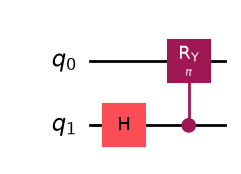

In [10]:
theta_10 = 2*np.arctan2(1, 0)
qc = QuantumCircuit(2)
qc.h( 1)
qc.cry(theta_10, 1, 0, ctrl_state='1') 


# results
print(theta_1,theta_00, theta_10)
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

Resulting Statevector:


<IPython.core.display.Latex object>

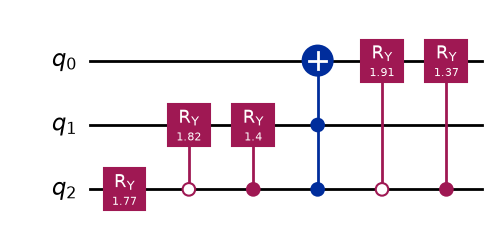

In [11]:

p = [0.05, 0.10, 0.15, 0.10, 0.20, 0.15, 0.10, 0.15]

# Level 1
theta_2   = 2*np.arctan2(np.sqrt(0.60), np.sqrt(0.40))
# Level 2
theta_02  = 2*np.arctan2(np.sqrt(0.25), np.sqrt(0.15))
theta_12  = 2*np.arctan2(np.sqrt(0.25), np.sqrt(0.35))
# Level 3
theta_002 = 2*np.arctan2(np.sqrt(p[1]), np.sqrt(p[0]))
theta_012 = 2*np.arctan2(np.sqrt(p[3]), np.sqrt(p[2]))
theta_102 = 2*np.arctan2(np.sqrt(p[5]), np.sqrt(p[4]))
theta_112 = 2*np.arctan2(np.sqrt(p[7]), np.sqrt(p[6]))

qc = QuantumCircuit(3)
# Level 1: rotate q2
qc.ry(theta_2, 2)
# Level 2: rotate q1 conditioned on q2
qc.cry(theta_02, 2, 1, ctrl_state='0')
qc.cry(theta_12, 2, 1, ctrl_state='1')
# Level 3: rotate q0 conditioned on (q2, q1)
qc.ccx(2, 1, 0)  # placeholder: see note below
qc.cry(theta_002, 2, 0, ctrl_state='0')  
qc.cry(theta_012, 2, 0, ctrl_state='1') 

state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

## Qiskit's initialize

In [12]:
from Chapter13_VectorEncoding_functions import gate_count

m = 10  # change this to any value
N = 2**m
print(f"Number of qubits (m): {m}")
# 1. Computational basis state e_0
b = np.zeros(N); b[0] = 1.0
print("e_0:                  ", gate_count(b, m))

# 2. Computational basis state e_1
b = np.zeros(N); b[1] = 1.0
print("e_1:                  ", gate_count(b, m))

# 3. Uniform superposition of first two states
b = np.zeros(N)
b[0] = 1/np.sqrt(2); b[1] = 1/np.sqrt(2)
print("Superposition 2:      ", gate_count(b, m))

# 4. Two-component real state (Ry rotation on qubit 0)
b = np.zeros(N)
b[0] = np.sqrt(3)/2; b[1] = 1/2
print("Two-component (Ry):   ", gate_count(b, m))

# 5. Uniform superposition (H^{otimes m})
b = np.ones(N) / np.sqrt(N)
print("Uniform superposition:", gate_count(b, m))

# 6. Alternating sign pattern (Walsh, X on qubit 0)
b = np.array([(-1)**k for k in range(N)],
             dtype=float) / np.sqrt(N)
print("Walsh alternating:    ", gate_count(b, m))

# 7. Block sign pattern (X on qubit m-1)
b = np.array([1.0]*(N//2) + [-1.0]*(N//2)) / np.sqrt(N)
print("Block sign:           ", gate_count(b, m))

# 8. Entangled state (Ry + CNOT), nonzero at indices 0 and N-1
b = np.zeros(N)
b[0] = np.sqrt(10)/5; b[N-1] = np.sqrt(15)/5
print("Entangled (Ry+CNOT):  ", gate_count(b, m))



Number of qubits (m): 10
e_0:                   (OrderedDict([('reset', 10)]), 10)
e_1:                   (OrderedDict([('u', 512), ('cx', 511), ('reset', 10)]), 1033)
Superposition 2:       (OrderedDict([('u', 512), ('cx', 511), ('reset', 10)]), 1033)
Two-component (Ry):    (OrderedDict([('u', 512), ('cx', 511), ('reset', 10)]), 1033)
Uniform superposition: (OrderedDict([('reset', 10), ('u', 10)]), 20)
Walsh alternating:     (OrderedDict([('reset', 10), ('u', 10)]), 20)
Block sign:            (OrderedDict([('u', 11), ('reset', 10), ('cx', 9)]), 30)
Entangled (Ry+CNOT):   (OrderedDict([('u', 1023), ('cx', 1013), ('reset', 10)]), 2046)
